# overview
This project analyzes the Titanic dataset using Python libraries such as Pandas, Matplotlib, and Seaborn. 
The goal is to clean the dataset, create useful features, and visualize important insights using different charts.

## Importing Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

## Loading Dataset

In [56]:
df = pd.read_csv("titanic_dataset.csv")
print("\nHead",df.head())
print("\ninfo",df.info())


Head    PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data col

# Interpretation
The dataset contains passenger information such as age, gender, fare, and survival status.
Some columns contain missing values that need cleaning.

## Data cleaning

In [57]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [58]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Fare"]=df["Fare"].fillna(df["Fare"].median())
df.drop("Cabin",axis = 1,inplace = True)

In [59]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Interpretation
Missing values in Age were replaced with the median age.
Cabin column was removed because most data was missing.

## Feature Engineering

In [60]:
#Create AgeGroup Feature
df["Age Group"] = pd.cut(df["Age"],
                         bins = [0,12,18,35,60,100],
                         labels=["Child","Teen","Young Adult","Adult","Senior"])
#Create FamilySize Feature
df["Family Size"] = df["SibSp"]+df["Parch"]
print(df[['Age Group', 'Family Size']].head())

     Age Group  Family Size
0  Young Adult            0
1        Adult            1
2       Senior            0
3  Young Adult            0
4  Young Adult            2


#Interpretation
FamilySize shows the number of family members traveling together.
AgeGroup helps categorize passengers by age range.

## Histogram

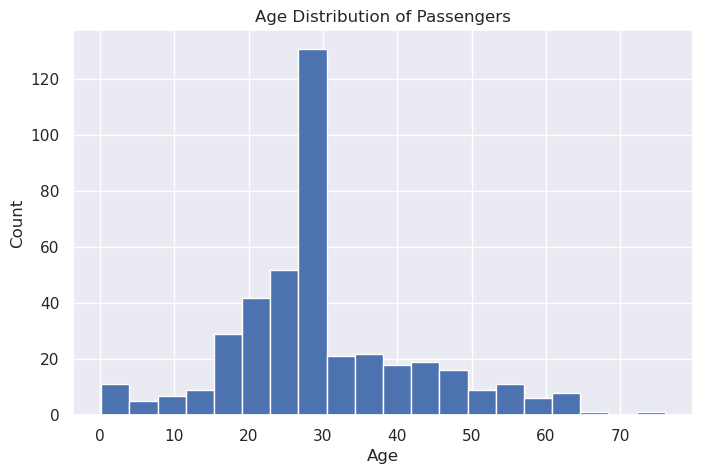

In [62]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

# Interpretation
Most passengers were between 20 and 40 years old.
Very few elderly passengers were present.

## Bar Chart - Survival by Gender

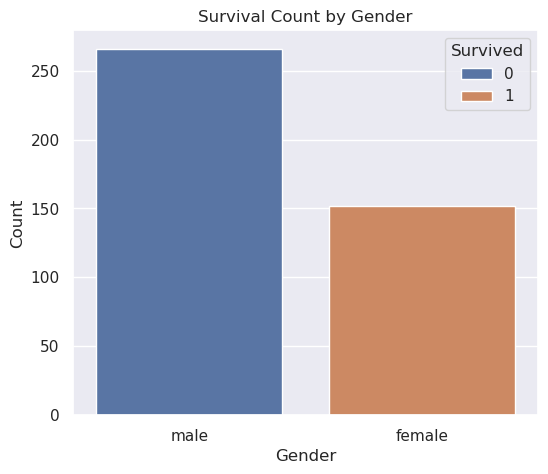

In [64]:
plt.figure(figsize=(6,5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived')
plt.show()

# Interpretation
Female passengers had a higher survival rate compared to males.
More male passengers did not survive.

## Boxplot of Fare by Passenger Class

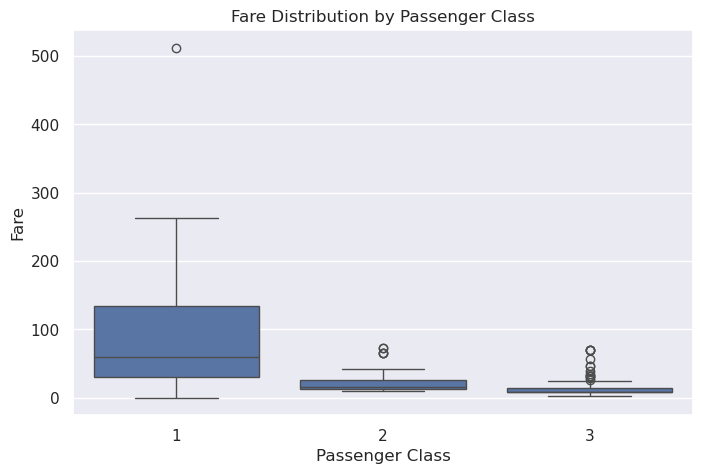

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

# Interpretation
First-class passengers paid significantly higher fares.
Outliers show some passengers paid extremely high ticket prices.

## Scatter Plot - Age vs Fare

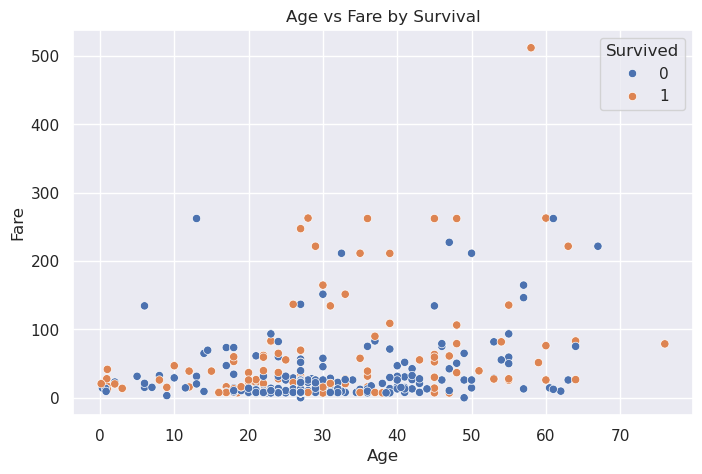

In [66]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

# Interpretation
Higher fare passengers had a better chance of survival.
There is no strong relationship between age and fare.

## Heatmap of Correlation Matrix

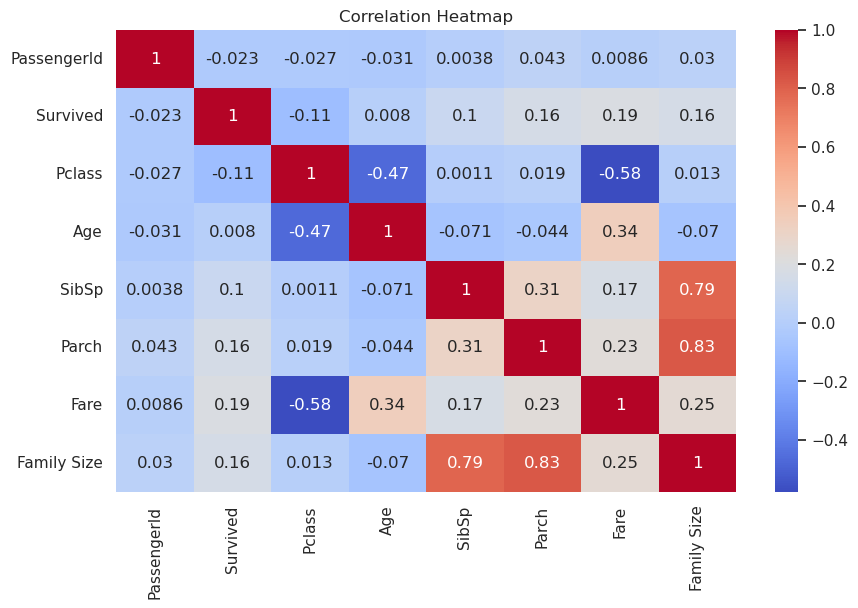

In [67]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Interpretation
Fare has a moderate relationship with passenger class.
Survival is slightly related to fare and passenger class.

In [ ]:
## Conclusion
This dashboard project demonstrates data cleaning, feature engineering, and data visualization using the Titanic dataset. 
The analysis helps understand patterns related to passenger survival and provides meaningful business insights through charts and interpretation.